## Week 9 Independet Lab: Inferential Statistics    
By: Dean Wilson  
Course: BGEN 632: Graduate Introduction to Python  
Date: 20250429  

### Modules Utilized

In [60]:
# load modules
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sts # for QQ plot
from scipy.stats import pearsonr # correlation p-values
from sklearn.linear_model import LinearRegression # regression output
import statsmodels.formula.api as smf # ols regression

### Directory

In [61]:
# Set working directory
os.chdir("C:\\Users\\deanb\\OneDrive\\Desktop\\Python Graduate Class\\Week 9\\Week9labs-main\\Week9labs-main\\data")  

# Confirm current working directory
os.getcwd()  

'C:\\Users\\deanb\\OneDrive\\Desktop\\Python Graduate Class\\Week 9\\Week9labs-main\\Week9labs-main\\data'

### File Utilized

In [62]:
ect_df = pd.read_table('ect_data.txt') # Opening file

### Regression Model / Independence: Intent1_01 as Target Variable

In [67]:
model1 = smf.ols('intent1_01 ~ attitude1_01 + attitude1_02 + attitude1_03 + peruse02 + peruse03', data=ect_df).fit() # ChatGPT helped me trouble shoot this, i had to add data=ect_df so i could assess independence of residuals at a later point

model1.summary() # show Regression / Independence

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             intent1_01   R-squared:                       0.505
Model:                            OLS   Adj. R-squared:                  0.492
Method:                 Least Squares   F-statistic:                     39.71
Date:                Tue, 29 Apr 2025   Prob (F-statistic):           4.95e-28
Time:                        19:33:14   Log-Likelihood:                -218.09
No. Observations:                 201   AIC:                             448.2
Df Residuals:                     195   BIC:                             468.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        1.4146      0.348      4.063      0.000       0.728       2.101
attitude1_01     0.4390      0.105      4.172      0.000       0.231       0.646
attitude1_02     0.1195      0.081      1.483      0.140      -0.039       0.278
attitude1_03    -0.0216      0.074     -0.292      0.771      -0.168       0.125
peruse02         0.0508      0.064      0.793      0.429      -0.076       0.177
peruse03         0.2074      0.072      2.897      0.004       0.066       0.349
==============================================================================
Omnibus:                       69.090   Durbin-Watson:                   1.913
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              317.079
Skew:                          -1.254   Prob(JB):                     1.40e-69
Kurtosis:                       8.618   Cond. No.                         91.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Regression Model Interpretation
* Prob (F-Statistic) was 4.95e-28, which is significantly smaller than our p value of .05, indicating that the model is overally statisticall significant. This explains a real realtionship between the predictors and intent1_01
* T-test:  attitude1_01 (p-value = .000) and peruse03 (p-vale = .004) were significant predictors of intent1_01, since their p-values were below .05. These predictors contribue to expalin the variance in intent1_01
* Durbin-Watson: The Durbin-Watson value is close to 2, suggesting no significant correlation in the residuals.

### Assessing Linearity & Homoscedasticity of Regression Model (Intent1_01)

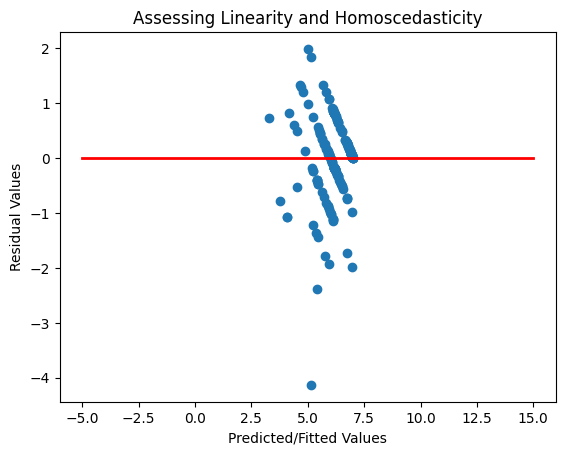

In [64]:
plt.scatter(model1.fittedvalues, model1.resid) # Plot the predicted and residuals
plt.xlabel('Predicted/Fitted Values') # X-Axis Label
plt.ylabel('Residual Values') # Y-Axis Label
plt.title('Assessing Linearity and Homoscedasticity') # Title
plt.plot([-5, 15],[0, 0], 'red', lw=2)   # add red horizontal line
plt.show() # Display Plot

### Linearity and Homoscedaasticity Findings
* With the residuals forming a borderline vertical line; all predications are the same, regardless of input variables

### Assessing Collinearity

In [68]:
# Utilized VIF, due to so many coefficients, I thought this was the best avenue. 
vif_model = LinearRegression(fit_intercept=True)
vif_model.fit(ect_df[['attitude1_01', 'attitude1_02', 'attitude1_03', 'peruse02', 'peruse03']], ect_df.intent1_01)

# calculate VIF for attitude1_01
vif_model.fit(ect_df[['attitude1_02', 'attitude1_03', 'peruse02', 'peruse03']], ect_df.attitude1_01)
vif1 = 1/(1 - vif_model.score(ect_df[['attitude1_02', 'attitude1_03', 'peruse02', 'peruse03']], ect_df.attitude1_01))

# calculate VIF for attitude1_02
vif_model.fit(ect_df[['attitude1_01', 'attitude1_03', 'peruse02', 'peruse03']], ect_df.attitude1_02)
vif2 = 1/(1 - vif_model.score(ect_df[['attitude1_01', 'attitude1_03', 'peruse02', 'peruse03']], ect_df.attitude1_02))

# calculate VIF for attitude1_03
vif_model.fit(ect_df[['attitude1_01', 'attitude1_02', 'peruse02', 'peruse03']], ect_df.attitude1_03)
vif3 = 1/(1 - vif_model.score(ect_df[['attitude1_01', 'attitude1_02', 'peruse02', 'peruse03']], ect_df.attitude1_03))

# calculate VIF for peruse02f
vif_model.fit(ect_df[['attitude1_01', 'attitude1_02', 'attitude1_03', 'peruse03']], ect_df.peruse02)
vif4 = 1/(1 - vif_model.score(ect_df[['attitude1_01', 'attitude1_02', 'attitude1_03', 'peruse03']], ect_df.peruse02))

# calculate VIF for peruse03
vif_model.fit(ect_df[['attitude1_01', 'attitude1_02', 'attitude1_03', 'peruse02']], ect_df.peruse03)
vif5 = 1/(1 - vif_model.score(ect_df[['attitude1_01', 'attitude1_02', 'attitude1_03', 'peruse02']], ect_df.peruse03))

# output VIF scores
print('VIF attitude1_01: ', vif1,
        '\nVIF attitude1_02: ', vif2,
        '\nVIF attitude1_03: ', vif3,
        '\nVIF peruse02: ', vif4,
        '\nVIF peruse03: ', vif5)

VIF attitude1_01:  3.669807339081974 
VIF attitude1_02:  2.830935160262436 
VIF attitude1_03:  2.3807216906045476 
VIF peruse02:  2.314397166694916 
VIF peruse03:  2.5852076818958976


### Collinearity Findings
* VIF Attitude1_01: Moderate collinearity with other predictors, but in ancceptable range  
* VIF Attitude1_02: No significant collinearity  
* VIF Attitude1_03: No significant collinearity  
* VIF Peruse02: No significant collinearity  
* VIF Peruse03: No significant collinearity

### Normality

((array([-2.70235077, -2.39300644, -2.21670641, -2.09047253, -1.99075721,
         -1.90762425, -1.83590295, -1.77254445, -1.71559368, -1.66371874,
         -1.61596971, -1.57164427, -1.53020786, -1.49124379, -1.45442067,
         -1.41947039, -1.38617282, -1.35434495, -1.32383285, -1.29450578,
         -1.26625169, -1.2389738 , -1.21258791, -1.18702027, -1.1622059 ,
         -1.13808725, -1.11461308, -1.09173755, -1.06941949, -1.04762177,
         -1.02631079, -1.005456  , -0.98502958, -0.96500611, -0.94536226,
         -0.92607659, -0.90712937, -0.88850233, -0.87017859, -0.85214246,
         -0.83437937, -0.81687572, -0.79961884, -0.78259687, -0.76579869,
         -0.74921388, -0.73283263, -0.71664571, -0.70064443, -0.68482057,
         -0.66916635, -0.65367443, -0.63833783, -0.62314992, -0.60810442,
         -0.59319534, -0.57841696, -0.56376385, -0.5492308 , -0.53481284,
         -0.52050522, -0.50630336, -0.49220289, -0.47819962, -0.4642895 ,
         -0.45046865, -0.43673331, -0.

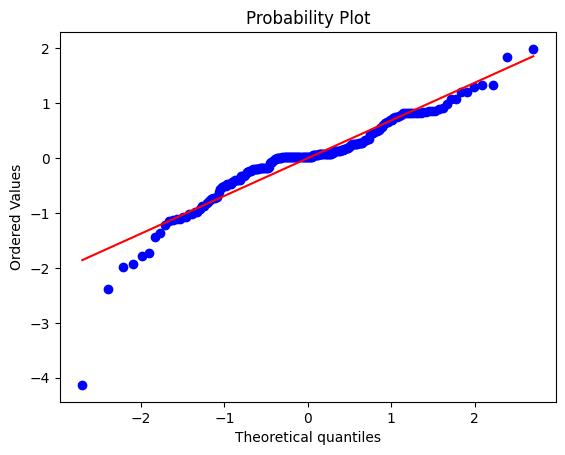

In [66]:
sts.probplot(model1.resid, dist="norm", plot=plt) ## QQ plot of model1

### Normality Findings
* The QQ plot shows that the residuals follow the red line closely, but the tail ends do show slight deviaion (especially the lower end). 

### Business Perspective of Attitude1_01 & Peruse03:
* Attitude1_01: I was unable to find the exact definition of this variable, so I will assume the following. Attitude1_01 is likely the customer's attitude toward the product/service. Since this predictor was statistically significant, we can assume that strong customer service or strong product reliability are increasing the customer's intent to purchase. I recommend that the business continue to improve customer perception through advertising and overall customer experience to increase overall sales.
* Peruse03: Like Attitude1_01, I was unable to find the exact definition for this variable, so I will assume the following. This is likely a variable that reflects how much a customer engages with the product. This can be time spent on an advertisement, do time spent on the company's landing page or even time spent on the actual product itself. A higher level of engagement reflects a strongerer posibility of customer purchasing intent. Recommend that the business invests more time and space for devloping better prodcut information, landing pages and advertisements/reviews. These will positively impact sales conversions.

### Regression Equation / Interpretation
* Equation: intent1_01 = 1.416 + 0.4390 (attitude1_01) + 0.1195 (attitude1_02) - 0.0216 (attitude1_03) + 0.0508 (peruse02) + 0.2074 (peruse03)
* Interpretation: Each coefficient represents the estimated change in intent1_01 (likely the customer's intent to purchase) for a one-unit increase in the corresponding predictor, holding all others costant. A one unit increase in attitude1_01 is associated with a 0.4390 unit increase in intent to purchase, while a one unit increase in attitude1_03 is decreases by .0216 intent to purchase. The model's overall F-test was significant, highlighting that all coefficients had some expalation for the variability in customer intent to purchase. 

### References
* OpenAI. (2025, April 29). ChatGPT response to regression model assumptions and QQ plot interpretation [Large language model]. https://chatgpt.com/share/68117d93-733c-8001-90c1-228e58f403eb